In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

02-Jun-26 13:15:11 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


In [4]:
font_path = "/home/z3536241/Fonts/arial.ttf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name

plt.rcParams['svg.fonttype'] = 'none'

## load layout files for multiple experiments

In [5]:
Experiment1Layout = pd.read_csv("/home/z3536241/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_Active_PolII/241026_mACmChPOLR2A_ActivePolII/METADATA/241026_mACmChPOLR2A_ActivePolII.csv")
Experiment2Layout = pd.read_csv("/home/z3536241/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_Active_PolII/241029_mACmChPOLR2A_ActivePolII/METADATA/241029_mACmChPOLR2A_ActivePolII.csv")
Experiment3Layout = pd.read_csv("/home/z3536241/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_Active_PolII/241111_mACmChPOLR2A_ActivePolII/METADATA/241111_mACmChPOLR2A_ActivePolII.csv")

## load quantification files and assemble into dataframes

In [6]:
Experiment1_Quantification_Directory_Cycle1 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/241026_mACmChPOLR2A_ActivePolII/20241029_180349_843/QUANTIFICATION/")
Experiment1_Quantification_Directory_Cycle2 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/241026_mACmChPOLR2A_ActivePolII/20241030_173018_319/QUANTIFICATION/")

Experiment2_Quantification_Directory_Cycle1 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/241029_mACmChPOLR2A_ActivePolII/20241101_183057_182/QUANTIFICATION/")
Experiment2_Quantification_Directory_Cycle2 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/241029_mACmChPOLR2A_ActivePolII/20241104_185759_772/QUANTIFICATION/")

Experiment3_Quantification_Directory_Cycle1 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/241111_mACmChPOLR2A_ActivePolII/20241114_190600_018/QUANTIFICATION/")
Experiment3_Quantification_Directory_Cycle2 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/241111_mACmChPOLR2A_ActivePolII/20241115_164752_840/QUANTIFICATION/")

Experiment1_Cycle1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory_Cycle1 / "*.csv"))
Experiment1_Cycle2_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory_Cycle2 / "*.csv"))

Experiment2_Cycle1_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory_Cycle1 / "*.csv"))
Experiment2_Cycle2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory_Cycle2 / "*.csv"))

Experiment3_Cycle1_Quantification_Files = glob.glob(str(Experiment3_Quantification_Directory_Cycle1 / "*.csv"))
Experiment3_Cycle2_Quantification_Files = glob.glob(str(Experiment3_Quantification_Directory_Cycle2 / "*.csv"))

[len(i) for i in [Experiment1_Cycle1_Quantification_Files, 
                 Experiment1_Cycle2_Quantification_Files, 
                 Experiment2_Cycle1_Quantification_Files, 
                 Experiment2_Cycle2_Quantification_Files,
                 Experiment3_Cycle1_Quantification_Files,
                 Experiment3_Cycle2_Quantification_Files]]

[958, 2155, 931, 2083, 955, 2155]

In [7]:
qdfs = list()


for f in tqdm(Experiment1_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment1_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment1_Cycle1 = pd.DataFrame({
    "WELL" : Experiment1_Cycle1_PerCell['well'],
    "RFP_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment1_Cycle1_PerCell['Nuclei_area']
})

100%|██████████| 958/958 [00:17<00:00, 55.15it/s]


In [8]:
qdfs = list()


for f in tqdm(Experiment1_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Cycle2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment1_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment1_Cycle2 = pd.DataFrame({
    "WELL" : Experiment1_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment1_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "NucleusArea2" : Experiment1_Cycle2_PerCell['Nuclei_area']
})

100%|██████████| 2155/2155 [00:39<00:00, 54.41it/s]


In [9]:
qdfs = list()


for f in tqdm(Experiment2_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment2_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment2_Cycle1 = pd.DataFrame({
    "WELL" : Experiment2_Cycle1_PerCell['well'],
    "RFP_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment2_Cycle1_PerCell['Nuclei_area']
})

100%|██████████| 931/931 [00:19<00:00, 46.89it/s]


In [10]:
qdfs = list()


for f in tqdm(Experiment2_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Cycle2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment2_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment2_Cycle2 = pd.DataFrame({
    "WELL" : Experiment2_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment2_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "NucleusArea2" : Experiment2_Cycle2_PerCell['Nuclei_area']
})

100%|██████████| 2083/2083 [00:42<00:00, 49.08it/s]


In [11]:
qdfs = list()


for f in tqdm(Experiment3_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment3_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment3_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment3_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment3_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment3_Cycle1 = pd.DataFrame({
    "WELL" : Experiment3_Cycle1_PerCell['well'],
    "RFP_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment3_Cycle1_PerCell['Nuclei_area']
})

100%|██████████| 955/955 [00:18<00:00, 50.29it/s]


In [12]:
qdfs = list()


for f in tqdm(Experiment3_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment3_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment3_Cycle2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment3_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment3_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment3_Cycle2 = pd.DataFrame({
    "WELL" : Experiment3_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment3_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "NucleusArea2" : Experiment3_Cycle2_PerCell['Nuclei_area']
})

100%|██████████| 2155/2155 [00:42<00:00, 50.28it/s]


## average by individual wells, add cell counts, and merge with layouts,

In [13]:
CountsByWell1 = Intensities_Experiment1_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1_Cycle1 = Intensities_Experiment1_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1_Cycle1 = IntensitiesByWell_Experiment1_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment1_Cycle2 = Intensities_Experiment1_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1_Cycle1.merge(IntensitiesByWell_Experiment1_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment1['EXPERIMENT'] = '241026_mACmChPOLR2A_ActivePolII'

In [14]:
CountsByWell2 = Intensities_Experiment2_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2_Cycle1 = Intensities_Experiment2_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2_Cycle1 = IntensitiesByWell_Experiment2_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment2_Cycle2 = Intensities_Experiment2_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2_Cycle1.merge(IntensitiesByWell_Experiment2_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment2['EXPERIMENT'] = '241029_mACmChPOLR2A_ActivePolII'

In [15]:
CountsByWell2 = Intensities_Experiment3_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment3_Cycle1 = Intensities_Experiment3_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment3Layout, how = 'left')
IntensitiesByWell_Experiment3_Cycle1 = IntensitiesByWell_Experiment3_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment3_Cycle2 = Intensities_Experiment3_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3_Cycle1.merge(IntensitiesByWell_Experiment3_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment3['EXPERIMENT'] = '241111_mACmChPOLR2A_ActivePolII'

## examine raw data per experiment

In [16]:
IntensitiesByWell_Experiment1.CELL.unique()

array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5',
       'HCT116 mChPOLR2A Clone 2',
       'HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1'], dtype=object)

In [17]:
IntensitiesByWell_Experiment1.DRUG.unique()

array(['No addition', '10 µM 5PhIAA', 'Vehicle'], dtype=object)

In [18]:
cell_relabel = dict(zip(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5','HCT116 mChPOLR2A Clone 2','HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1'],
                        ['OsTIRF74G', 'mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A']))

### experiment 1

/scratch/pbs.8169695.kman.restech.unsw.edu.au/ipykernel_2400133/3773484762.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment1_Baseline['CELL'].map(cell_relabel)


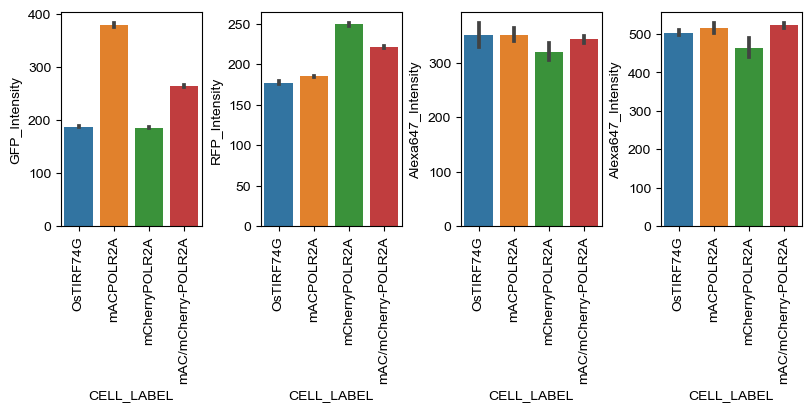

In [19]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment1_Baseline = IntensitiesByWell_Experiment1.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment1_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment1_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment1_Baseline,
            x = 'CELL_LABEL', order = ['OsTIRF74G', 'mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'],
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment1_Baseline,
            x = 'CELL_LABEL', order = ['OsTIRF74G', 'mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'],
            y = 'RFP_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment1_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL', order = ['OsTIRF74G', 'mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'],
            y = 'Alexa647_Intensity',
            ax = a[2])

sns.barplot(IntensitiesByWell_Experiment1_Baseline.query('PRIMARY == "pSer2 3E10"'),
            x = 'CELL_LABEL', order = ['OsTIRF74G', 'mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'],
            y = 'Alexa647_Intensity',
            ax = a[3])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

### experiment 2

/scratch/pbs.8169695.kman.restech.unsw.edu.au/ipykernel_2400133/1839796053.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment2_Baseline['CELL'].map(cell_relabel)


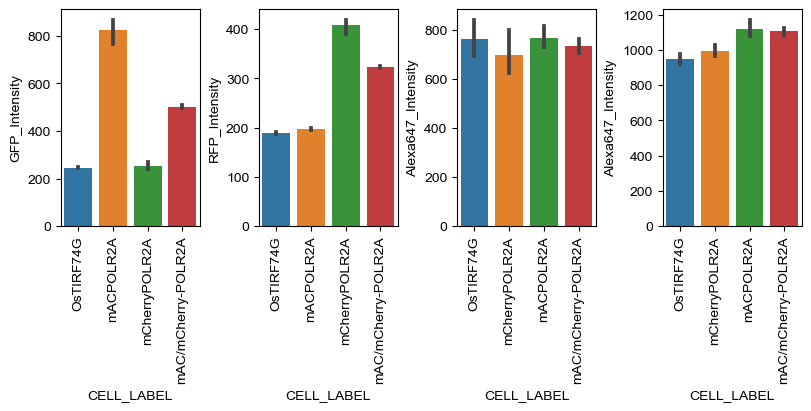

In [20]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment2_Baseline = IntensitiesByWell_Experiment2.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment2_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment2_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment2_Baseline,
            x = 'CELL_LABEL',
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment2_Baseline,
            x = 'CELL_LABEL',
            y = 'RFP_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment2_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL',
            y = 'Alexa647_Intensity',
            ax = a[2])

sns.barplot(IntensitiesByWell_Experiment2_Baseline.query('PRIMARY == "pSer2 3E10"'),
            x = 'CELL_LABEL',
            y = 'Alexa647_Intensity',
            ax = a[3])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)
    

### experiment 3

/scratch/pbs.8169695.kman.restech.unsw.edu.au/ipykernel_2400133/2378267435.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment3_Baseline['CELL'].map(cell_relabel)


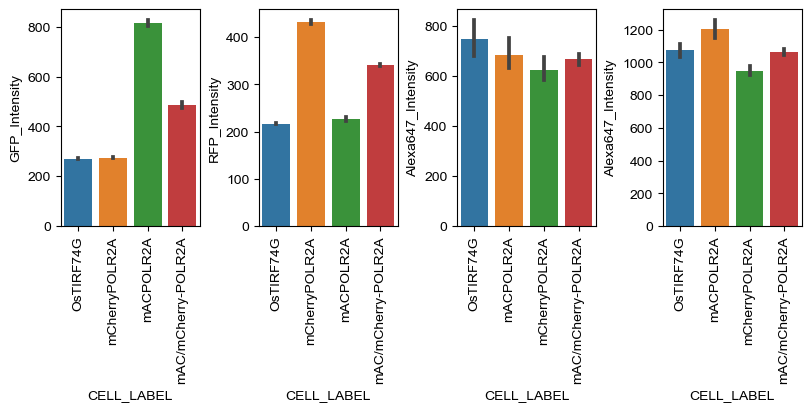

In [21]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment3_Baseline = IntensitiesByWell_Experiment3.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment3_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment3_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment3_Baseline,
            x = 'CELL_LABEL',
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment3_Baseline,
            x = 'CELL_LABEL',
            y = 'RFP_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment3_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL',
            y = 'Alexa647_Intensity',
            ax = a[2])

sns.barplot(IntensitiesByWell_Experiment3_Baseline.query('PRIMARY == "pSer2 3E10"'),
            x = 'CELL_LABEL',
            y = 'Alexa647_Intensity',
            ax = a[3])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

## background subtract and normalise within experiments

### RFP and GFP

In [22]:
E1_GFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E2_GFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E3_GFP_Zero = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['GFP_Intensity'] - E1_GFP_Zero
IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['GFP_Intensity'] - E2_GFP_Zero
IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment3['GFP_Intensity'] - E3_GFP_Zero

E1_GFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()
E2_GFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()
E3_GFP_NV = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_FC'] = IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] / E1_GFP_NV
IntensitiesByWell_Experiment2['GFP_Intensity_FC'] = IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] / E2_GFP_NV
IntensitiesByWell_Experiment3['GFP_Intensity_FC'] = IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] / E3_GFP_NV

In [23]:
E1_RFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').RFP_Intensity.mean()
E2_RFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').RFP_Intensity.mean()
E3_RFP_Zero = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G"').RFP_Intensity.mean()

IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['RFP_Intensity'] - E1_RFP_Zero
IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['RFP_Intensity'] - E2_RFP_Zero
IntensitiesByWell_Experiment3['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment3['RFP_Intensity'] - E3_RFP_Zero

E1_RFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG == "Vehicle"').RFP_Intensity_BGS.mean()
E2_RFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG == "Vehicle"').RFP_Intensity_BGS.mean()
E3_RFP_NV = IntensitiesByWell_Experiment3.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG == "Vehicle"').RFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['RFP_Intensity_FC'] = IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] / E1_RFP_NV
IntensitiesByWell_Experiment2['RFP_Intensity_FC'] = IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] / E2_RFP_NV
IntensitiesByWell_Experiment3['RFP_Intensity_FC'] = IntensitiesByWell_Experiment3['RFP_Intensity_BGS'] / E3_RFP_NV

In [24]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2, IntensitiesByWell_Experiment3])

### immunofluorescence

In [26]:
# normalising immunofluorescence values to HCT116 OsTIRF74G cells to compare across cell lines

In [38]:
E1_Mouse_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').Alexa647_Intensity.mean()
E2_Mouse_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').Alexa647_Intensity.mean()
E3_Mouse_Zero = IntensitiesByWell_Experiment3.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').Alexa647_Intensity.mean()

E1_Rat_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').Alexa647_Intensity.mean()
E2_Rat_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').Alexa647_Intensity.mean()
E3_Rat_Zero = IntensitiesByWell_Experiment3.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').Alexa647_Intensity.mean()


Total_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('PRIMARY == "Total Pol II F12"')
Total_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('PRIMARY == "Total Pol II F12"')
Total_IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('PRIMARY == "Total Pol II F12"')

Total_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_Mouse_Zero
Total_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['Alexa647_Intensity'] - E2_Mouse_Zero
Total_IntensitiesByWell_Experiment3['Alexa647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment3['Alexa647_Intensity'] - E3_Mouse_Zero

E1_Total_NV = Total_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').Alexa647_Intensity_BGS.mean()
E2_Total_NV = Total_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').Alexa647_Intensity_BGS.mean()
E3_Total_NV = Total_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G"').Alexa647_Intensity_BGS.mean()

Total_IntensitiesByWell_Experiment1['Alexa647_Intensity_FC'] = Total_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] / E1_Total_NV
Total_IntensitiesByWell_Experiment2['Alexa647_Intensity_FC'] = Total_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] / E2_Total_NV
Total_IntensitiesByWell_Experiment3['Alexa647_Intensity_FC'] = Total_IntensitiesByWell_Experiment3['Alexa647_Intensity_BGS'] / E3_Total_NV


pSer2_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('PRIMARY == "pSer2 3E10"')
pSer2_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('PRIMARY == "pSer2 3E10"')
pSer2_IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('PRIMARY == "pSer2 3E10"')

pSer2_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_Rat_Zero
pSer2_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment2['Alexa647_Intensity'] - E2_Rat_Zero
pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity'] - E3_Rat_Zero

E1_pSer2_NV = pSer2_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').Alexa647_Intensity_BGS.mean()
E2_pSer2_NV = pSer2_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').Alexa647_Intensity_BGS.mean()
E3_pSer2_NV = pSer2_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G"').Alexa647_Intensity_BGS.mean()

pSer2_IntensitiesByWell_Experiment1['Alexa647_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] / E1_pSer2_NV
pSer2_IntensitiesByWell_Experiment2['Alexa647_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] / E2_pSer2_NV
pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity_BGS'] / E3_pSer2_NV

/scratch/pbs.8169695.kman.restech.unsw.edu.au/ipykernel_2400133/529769076.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_Mouse_Zero
/scratch/pbs.8169695.kman.restech.unsw.edu.au/ipykernel_2400133/529769076.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['Alexa647_Intensity'

In [40]:
Total_IntensitiesByWell = pd.concat([Total_IntensitiesByWell_Experiment1, Total_IntensitiesByWell_Experiment2, Total_IntensitiesByWell_Experiment3])
pSer2_IntensitiesByWell = pd.concat([pSer2_IntensitiesByWell_Experiment1, pSer2_IntensitiesByWell_Experiment2, pSer2_IntensitiesByWell_Experiment3])

# publication plots

## normalised GFP, RFP, total Pol II, and pSer2 Pol II plots

In [64]:
IntensitiesByWell.CELL.unique()

array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5',
       'HCT116 mChPOLR2A Clone 2',
       'HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1'], dtype=object)

/scratch/pbs.8169695.kman.restech.unsw.edu.au/ipykernel_2400133/1995107305.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Plot['CELL_LAB'] = IntensitiesByWell_Plot.CELL.map(cell_relab)
/scratch/pbs.8169695.kman.restech.unsw.edu.au/ipykernel_2400133/1995107305.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Plot['CELL_LAB'] = Total_IntensitiesByWell_Plot.CELL.map(cell_relab)
/scratch/pbs.8169695.kman.restech.unsw.edu.au/ipykernel_2400133/1995107305.py:17: 

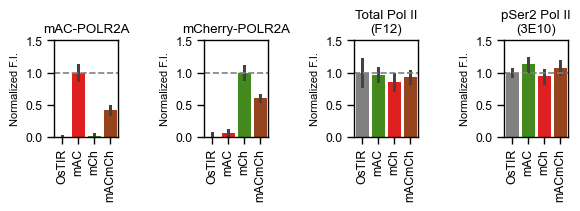

In [84]:
sns.set_context('paper')

cell_relab = dict(zip(['HCT116 OsTIRF74G', 
                       'HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5',
                       'HCT116 mChPOLR2A Clone 2',
                       'HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1'],
                      ['OsTIR', 'mAC', 'mCh', 'mACmCh']))

pal = sns.color_palette(['grey', 'red', 'xkcd:grass green', 'xkcd:rust'])

IntensitiesByWell_Plot = IntensitiesByWell.query('DRUG == "Vehicle" | DRUG == "No addition"')
Total_IntensitiesByWell_Plot = Total_IntensitiesByWell.query('DRUG == "Vehicle" | DRUG == "No addition"')
pSer2_IntensitiesByWell_Plot = pSer2_IntensitiesByWell.query('DRUG == "Vehicle" | DRUG == "No addition"')

IntensitiesByWell_Plot['CELL_LAB'] = IntensitiesByWell_Plot.CELL.map(cell_relab)
Total_IntensitiesByWell_Plot['CELL_LAB'] = Total_IntensitiesByWell_Plot.CELL.map(cell_relab)
pSer2_IntensitiesByWell_Plot['CELL_LAB'] = pSer2_IntensitiesByWell_Plot.CELL.map(cell_relab)

f, a = plt.subplots(ncols = 4, figsize = (6,2
                                         ), layout = 'constrained')

h = sns.barplot(IntensitiesByWell_Plot, 
             x = 'CELL_LAB', order = ['OsTIR', 'mAC', 'mCh', 'mACmCh'], 
            hue = 'CELL_LAB', palette = pal,
             y = 'GFP_Intensity_FC',
             errorbar = 'sd',
             ax = a[0],
            dodge = False)
h.get_legend().remove()

h = sns.barplot(IntensitiesByWell_Plot, 
             x = 'CELL_LAB', order = ['OsTIR', 'mAC', 'mCh', 'mACmCh'],
            hue = 'CELL_LAB', palette = pal,
             y = 'RFP_Intensity_FC',
             errorbar = 'sd',
             ax = a[1],
            dodge = False)
h.get_legend().remove()

h = sns.barplot(Total_IntensitiesByWell_Plot, 
             x = 'CELL_LAB', order = ['OsTIR', 'mAC', 'mCh', 'mACmCh'],
            hue = 'CELL_LAB', palette = pal,
             y = 'Alexa647_Intensity_FC',
             errorbar = 'sd',
             ax = a[2],
            dodge = False)
h.get_legend().remove()

h = sns.barplot(pSer2_IntensitiesByWell_Plot, 
             x = 'CELL_LAB', order = ['OsTIR', 'mAC', 'mCh', 'mACmCh'],
            hue = 'CELL_LAB', palette = pal,
             y = 'Alexa647_Intensity_FC',
             errorbar = 'sd',
             ax = a[3],
            dodge = False)
h.get_legend().remove()

a[0].set_title('mAC-POLR2A')
a[1].set_title('mCherry-POLR2A')
a[2].set_title('Total Pol II\n(F12)')
a[3].set_title('pSer2 Pol II\n(3E10)')

for i in range(4):
    a[i].set_box_aspect(1.5)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_ylim(0,1.5)
    a[i].set_yticks([0,0.5,1,1.5])
    a[i].tick_params(axis = 'x', labelrotation = 90)
    a[i].axhline(1, linestyle = '--', color = 'grey')
    a[i].set_xlabel('')

plt.savefig('OsTIRF_mAC_mCh_mACmChPOLR2A_baseline_F12_3E10.svg')